# Bathymetry and Boundaries for AMR-Wind from FVCOM

##### Notes: 
##### 1. FVCOM only contains bathymetry data, but in AMR-Wind we plan to simulate two-phase flow, so both air and water (even if we have no wind).  This code gets the bathymetry data from the FVCOM output, and it gets land elevation data from Shuttle Radar Topography Mission (SRTM) data.  Although the SRTM data shows ocean surfaces as roughly zero elevation, there is not a distinct land/water line, so the code then uses the SRTM Water Body Data set to find the merge line between the underwater/land data sets.  
##### 2. The FVCOM data also contains information about the water surface height, which changes in time, for example, because of tides.  We attempt to use that information in writing boundary data concerning phase and density.

In [1]:
# Load modules.

# Load ipython methods for module reloading at runtime.  Useful if a module
# gets updated between running of this notebook.
#%load_ext autoreload
#%autoreload 2

import numpy as np
import matplotlib.path as mpath          # for masking land elevation data inside of closed coastline polygons
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import pathlib                           
import netCDF4 as nc                     # for reading FVCOM netcdf data.
import xarray as xr                      # for manipulating FVCOM netcdf data.
import shapefile as shpfl                # necessary to read in coastline shape file.
import inflowPrepMMC as mmc              # from MMC project. Helpful for writing AMR-Wind terrain data.
import terrain as terrain                # from MMC project. Required to automatically get SRTM data and manipulate it.
import amrex.space3d as amr              # from pyamrex, which is required to use Marc's library below
import native_boundary_plane as nbp      # Marc's boundary data manipulation library
import boundaryDataFunctors              # Matt's own library of functors necessary to work with Marc's AMReX boundary data writer.
import scipy as sc                       # for interpolation
from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import NearestNDInterpolator




plt.rcParams['axes.grid'] = True
plt.rcParams['figure.autolayout'] = True

# Set number of OMP threads to 1 in case of newer pyamrex that uses OMP
import os
os.environ["OMP_NUM_THREADS"] = "1"



In [ ]:
### User input.

# Path to both the raw and reduced FVCOM data.
rawPath = '/projects/hfm/churchfield/rosario/FVCOM/WA_puget_sound/v1.0.0/00_raw/Puget_Sound_corrected/20150331_20150501/'
reducedPath = '/projects/hfm/churchfield/rosario/FVCOM/WA_puget_sound/v1.0.0/00_raw/Puget_Sound_corrected/20150331_20150501/reduced/'

# Path to location to save SRTM elevation data for land around Rosario Strait.
srtmDataPath = '/projects/hfm/churchfield/estuary_hfm_mmsei/tools/FVCOM-dataExtraction/rosario.tif'

# Path to SRTM water body data set for Rosario Strait region.
waterBodyPath = '/projects/hfm/churchfield/estuary_hfm_mmsei/tools/FVCOM-dataExtraction/w123n48n.shp'

#UTM Zone of Rosario Strait.
UTMzone = '10 U'

# Deployment location.
Stablemoor_latlong = [48.56260, -122.76690]
Stablemoor_FVCOM_latlong = [48.5626, -122.7669]
SeaSpider_latlong = [48.56270, -122.76510]
SeaSpider_FVCOM_latlong = [48.5628, -122.7650]
SurfaceBuoy_latlong = [48.56280, -122.76220]
SurfaceBuoy_FVCOM_latlong = [48.5628, -122.7620]

coords = mmc.inflowPrepMMC()
Stablemoor_UTMx, Stablemoor_UTMy, Stablemoor_UTMzone = coords.LatLonToUTM(Stablemoor_latlong[0],Stablemoor_latlong[1])
if (Stablemoor_UTMzone != UTMzone):
    print("Warning: UTM zone of STBM does not match specified UTM zone.")
deploymentSTBM = [Stablemoor_UTMx, Stablemoor_UTMy]
SeaSpider_UTMx, SeaSpider_UTMy, SeaSpider_UTMzone = coords.LatLonToUTM(SeaSpider_latlong[0],SeaSpider_latlong[1])
if (SeaSpider_UTMzone != UTMzone):
    print("Warning: UTM zone of SS does not match specified UTM zone.")
deploymentSS = [SeaSpider_UTMx, SeaSpider_UTMy]

# UTM coordinates that AMR-Wind x,y lo correspond to.
# This is specified later, so it's commented out for now
#xyzLoUTM = [510000.0, 5376500.0, 0.0]
# z coordinate will be replaced

# AMR-Wind terrain file location.
terrainFile = '/scratch/mkuhn/estuary_flows/milestone/terrain.amrwind'

# The terrain file will be larger than what we specify as xyzLo/Hi by x/yBuffer on each side.
xBuffer = 1000.0
yBuffer = 1000.0

# Boundary fields to write.  This script does not support writing to zlo and zhi boundaries, but we should never
# need those anyway.
boundaries = ['xlo','xhi','ylo','yhi']

# Variables to write on the boundaries.
fields = [
            "velocity",
            "density",
            "vof"
         ]

# Components in each variable (1: scalar, 3: vector, 6: symmetric tensor, 9: tensor).
components = [
                3, 
                1,
                1
             ]


# FVCOM time is in days starting at a very big number, 57023.  It appears to be time since the origin of the Modified Julian Day,
# which is November 17, 1858 at midnight

FVCOM_initial_time = 5.7023E4 # January 1, 2015

FVCOM_april = FVCOM_initial_time + 31. + 28. + 31. # I checked -- no leap day
startDay = 5
startHour = 30


startTime = FVCOM_april + startDay + startHour/24.0
duration_hours = 12.5

duration_days = duration_hours / 24.0
endTime = startTime + duration_days
boundaryDataTimeRange = [startTime, endTime] # A 12.5 hour range

# To speed boundary data interpolation, create interpolator that is only +/- interpSubsetDist from AMR-Wind boundary.
interpSubsetDist = 100.0

# Type of interpolation by variable.  These are my current recommendations.
#     -nearest for velocity otherwise strange things can happen near the bottom surface, but linear may fine--test more...
#     -nearest for water surface level because we need a reliable value even inside terrain far from FVCOM data, so nearest
#      works well for this.
#     -linear for elevation of bathymetry/terrain because this is well defined everywhere so there should be no extrapolation,
#      so linear will work well.
interpolatorTypeVelocity = 'nearest'
interpolatorTypeZeta = 'nearest'
interpolatorTypeHeight = 'linear'

# Boundary velocities in the air and inside terrain.
terrainVel = [0.0, 0.0, 0.0]
airVel = [0.0, 0.0, 0.0]

# Density.
waterDensity = 1025.0   # for seawater
airDensity = 1.225

# Volume of fluid.
waterVOF = 1.0
airVOF = 0.0

#  AMR-Wind input file path.  Used so that pyamrex can build the domain and boundaries.
AMRWindInputFile = '/scratch/mkuhn/estuary_flows/milestone/max_lev2/rosario.inp'
AMRWindBoundaryDataDirectory = '/scratch/mkuhn/estuary_flows/milestone/max_lev2/bndry_files'

#  Overwrite existing AMR-Wind boundary data.
AMRWindBoundaryDataOverwrite = True





In [3]:
# ### Load FVCOM data from raw NetCDF and then save reduced data in numpy format for fast reading later.
# for ifile in range(7):
#     # This assumes that everything is the same between files except for u, v, and zeta
#     ds = nc.Dataset(rawPath+'psm_000'+str(ifile+1)+'.nc','r')
#     UTMbounds = np.array([[5.375e6,5.3815e6],[514000,521000]])
#     inpoint = [518000,5.3765e6]
#     invec = [0,1]
#     dist = np.abs(np.transpose([ds['xc'][:].data-inpoint[0],ds['yc'][:].data-inpoint[1]]) @ invec)
#     UTMcoords = np.array(ds['yc'][:].data > np.min(UTMbounds[0])) & np.array(ds['yc'][:].data < np.max(UTMbounds[0])) & np.array(ds['xc'][:].data > np.min(UTMbounds[1])) & np.array(ds['xc'][:].data < np.max(UTMbounds[1]))
#     iin = UTMcoords & np.array(dist<100)
#     zeta_c = np.zeros((ds['time'][:].data.shape[0],ds['xc'][:].data.shape[0]))
#     for t in range(zeta_c.shape[0]):
#         zeta_c[t,:] = np.mean(ds['zeta'][t,:].data[ds['nv'][:].data[:,:]-1],0)

#     time = np.array(ds['time'][:].data)
#     x = np.array(ds['xc'][UTMcoords].data); 
#     y = np.array(ds['yc'][UTMcoords].data); 
#     h = np.array(ds['h_center'][UTMcoords].data); 
#     nv = np.array(ds['nv'][:,UTMcoords].data) - 1; 
#     siglay = np.array(ds['siglay_center'][:,UTMcoords].data); 
#     u = np.zeros((ds['u'].shape[0],ds['u'].shape[1],len(x)))
#     v = np.zeros((ds['v'].shape[0],ds['v'].shape[1],len(x)))
#     zeta = np.zeros((ds['zeta'].shape[0],ds['zeta'].shape[1]))
#     for t in range(u.shape[0]):
#         zeta[t,:] = ds['zeta'][t,:].data
#         for z in range(u.shape[1]):
#             u[t,z,:] = ds['u'][t,z,UTMcoords].data
#             v[t,z,:] = ds['v'][t,z,UTMcoords].data
#     if (ifile == 0):
#         u_write = u
#         v_write = v
#         zeta_write = zeta
#         time_write = time
#     else:
#         u_write = np.concatenate((u_write,u),axis=0)
#         v_write = np.concatenate((v_write,v),axis=0)
#         zeta_write = np.concatenate((zeta_write,zeta),axis=0)
#         time_write = np.concatenate((time_write,time),axis=0)

# np.save(reducedPath+'PS_time.npy',time_write)
# np.save(reducedPath+'PS_x.npy',x)
# np.save(reducedPath+'PS_y.npy',y)
# np.save(reducedPath+'PS_h.npy',h)
# np.save(reducedPath+'PS_nv.npy',nv)
# np.save(reducedPath+'PS_siglay.npy',siglay)
# np.save(reducedPath+'PS_u.npy',u_write)
# np.save(reducedPath+'PS_v.npy',v_write)
# np.save(reducedPath+'PS_zeta.npy',zeta_write)


In [4]:
# Rather than load all the FVCOM data, which is slow, Will loaded and then saved some of the data in 
# numpy format.  That's what gets loaded here.  Still one NetCDF file gets loaded just to get some basic
# location information.

time = np.load(reducedPath+'PS_time.npy')
xBathymetry = np.load(reducedPath+'PS_x.npy');   # east direction
yBathymetry = np.load(reducedPath+'PS_y.npy');   # north direction
hBathymetry = -np.load(reducedPath+'PS_h.npy');  # depth
nv = np.load(reducedPath+'PS_nv.npy');
siglay = np.load(reducedPath+'PS_siglay.npy');   # normalized depth: sigma = -(z+H)/(zeta+H), where z is height, H is bottom depth, and zeta is sea surface elevation.
u = np.load(reducedPath+'PS_u.npy');             # east velocity
v = np.load(reducedPath+'PS_v.npy');             # north velocity
zeta_node = np.load(reducedPath+'PS_zeta.npy');  # water surface elevation at nodes.
zeta = np.zeros((len(time),len(xBathymetry)))              # water surface elevation at cell centers.
for t in range(zeta.shape[0]):
    zeta[t,:] = np.mean(zeta_node[t,nv])


# Find indices of bounding times to write boundary data for.
timeIndex = [0, 0]
timeIndex[0] = np.argmin(np.abs(time - boundaryDataTimeRange[0]))
timeIndex[1] = np.argmin(np.abs(time - boundaryDataTimeRange[1]))


# Print summary.
print('             min                 max')
print('xBathymetry:',np.min(xBathymetry),np.max(xBathymetry),'m')
print('yBathymetry:',np.min(yBathymetry),np.max(yBathymetry),'m')
print('hBathymetry:',np.min(hBathymetry),np.max(hBathymetry),'m')
print('time:',np.min(time),np.max(time),'days since November 17, 1858 at midnight')



    

             min                 max
xBathymetry: 514004.8 520995.38 m
yBathymetry: 5.3750015e+06 5.3814995e+06 m
hBathymetry: -139.36594 4.8402476 m
time: 57112.0 57143.0 days since November 17, 1858 at midnight


In [5]:
### Get terrain data for above water part from Shuttle Radar Topography Mission (SRTM) dataset.


# Use the tools in inflowPrepMMC to convert from the UTM bounds of the FVCOM data to latitude/longitude
coords = mmc.inflowPrepMMC()
latLo,lonLo = coords.UTMtoLatLon(np.min(xBathymetry),np.min(yBathymetry),UTMzone)
latHi,lonHi = coords.UTMtoLatLon(np.max(xBathymetry),np.max(yBathymetry),UTMzone)

# Set up the SRTM data handler.
srtmBounds = (lonLo, latLo, lonHi, latHi)
srtm = terrain.SRTM(srtmBounds, fpath=srtmDataPath, product='SRTM1')

# Download the data as a geotiff.
srtm.download()

# Convert the geotiff data to useable x, y, z data
xTerrain,yTerrain,hTerrain = srtm.to_terrain()
xTerrain = xTerrain.flatten()
yTerrain = yTerrain.flatten()
hTerrain = hTerrain.flatten()





make: Entering directory '/home/mkuhn/.cache/elevation/SRTM1'
make: Nothing to be done for 'download'.
make: Leaving directory '/home/mkuhn/.cache/elevation/SRTM1'
make: Entering directory '/home/mkuhn/.cache/elevation/SRTM1'
make: Nothing to be done for 'all'.
make: Leaving directory '/home/mkuhn/.cache/elevation/SRTM1'
make: Entering directory '/home/mkuhn/.cache/elevation/SRTM1'
cp SRTM1.vrt SRTM1.759b59dc4ce2460986137ae702d2a49e.vrt
make: Leaving directory '/home/mkuhn/.cache/elevation/SRTM1'
make: Entering directory '/home/mkuhn/.cache/elevation/SRTM1'
gdal_translate -q -co TILED=YES -co COMPRESS=DEFLATE -co ZLEVEL=9 -co PREDICTOR=2 -projwin -122.86031 48.636227 -122.6653 48.477966 SRTM1.759b59dc4ce2460986137ae702d2a49e.vrt /projects/hfm/churchfield/estuary_hfm_mmsei/tools/FVCOM-dataExtraction/rosario.tif


Warning 1: PROJ: proj_create_from_database: Open of /home/mkuhn/.conda-envs/estuary_env/share/proj failed
ERROR 1: PROJ: proj_create_from_name: Open of /home/mkuhn/.conda-envs/estuary_env/share/proj failed


rm -f SRTM1.759b59dc4ce2460986137ae702d2a49e.vrt
make: Leaving directory '/home/mkuhn/.cache/elevation/SRTM1'
make: Entering directory '/home/mkuhn/.cache/elevation/SRTM1'
find cache -size 0 -name "*.tif" -delete
rm -f SRTM1.*.vrt
rm -f -r spool/*
make: Leaving directory '/home/mkuhn/.cache/elevation/SRTM1'
Output grid at ds= 30.0
Projecting from EPSG:4326 to EPSG:32610


Text(0, 0.5, 'y-UTM (m)')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


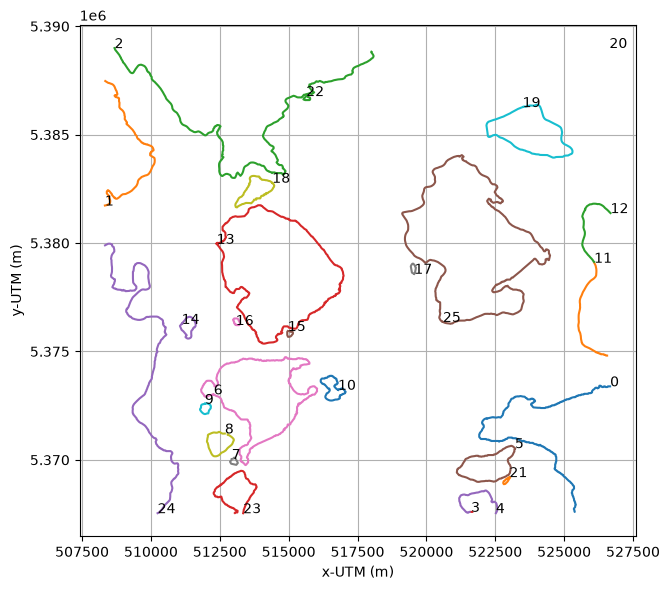

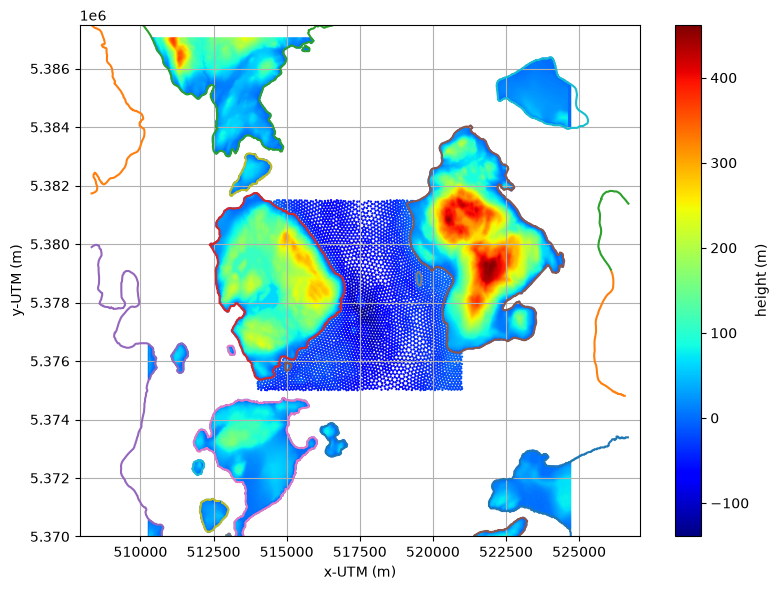

In [6]:
### Get coastal location data from SRTM Water Body Data set.

# I downloaded the data around Rosario Strait from https://earthexplorer.usgs.gov/.  The file is a ESRI shapefile.  It contains
# distinct sets of points for different bodies of water.  Most are lakes and rivers, but set 45 is the Pacific, which outlines the
# islands that create Rosario Strait.

# Read in the shape file using pyshp.
sf = shpfl.Reader(waterBodyPath)

# Extract the Pacific coastline data.  The data is in lat/lon, so convert to UTM.
indexPacific = 45
waterBody = np.array(sf.shape(indexPacific).points)
xWaterBody,yWaterBody,dd = coords.LatLonToUTM(waterBody[:,1],waterBody[:,0],UTMzone)

# The downloaded water body data covers a large geographic extent, so this part cuts it down to a smaller region more
# focused on the region of interest.
maskWBData = True
xBuffer = 2000.0
yBuffer = 2000.0
if (maskWBData):
    mask = np.where(xWaterBody > np.min(xTerrain)-xBuffer)
    xWaterBody = xWaterBody[mask]
    yWaterBody = yWaterBody[mask]
    
    mask = np.where(xWaterBody < np.max(xTerrain)+xBuffer)
    xWaterBody = xWaterBody[mask]
    yWaterBody = yWaterBody[mask]
    
    mask = np.where(yWaterBody > np.min(yTerrain)-yBuffer)
    xWaterBody = xWaterBody[mask]
    yWaterBody = yWaterBody[mask]
    
    mask = np.where(yWaterBody < np.max(yTerrain)+yBuffer)
    xWaterBody = xWaterBody[mask]
    yWaterBody = yWaterBody[mask]


# The Pacific coastline is contained in a single polygon, so it does not distinguish islands from each other.  Look for jumps in distance
# between consecutive points as an indicator of a new island and split to coordinates by island.
xx = []
yy = []
xx_ = []
yy_ = []
jumpDistThreshold = 750.0
for i in range(1,len(xWaterBody)-1):
    ds = np.sqrt(np.square(xWaterBody[i+1] - xWaterBody[i]) + 
                 np.square(yWaterBody[i+1] - yWaterBody[i]))
    if (ds < jumpDistThreshold):
        xx_.append(xWaterBody[i])
        yy_.append(yWaterBody[i])
    else:
        xx.append(np.asarray(xx_))
        yy.append(np.asarray(yy_))
        xx_ = []
        yy_ = []

xIsland = xx
yIsland = yy
del xx, yy, xx_, yy_


# Come up with a terrain elevation map mask to only include data inside the boundaries of islands and disclude anything in the water.
nIsland = len(xIsland)

xyTerrain = np.zeros((len(xTerrain),2))
xyTerrain[:,0] = xTerrain
xyTerrain[:,1] = yTerrain

insideMask = []
for i in range(nIsland):
    xyIsland = np.zeros((len(xIsland[i]),2))
    xyIsland[:,0] = xIsland[i]
    xyIsland[:,1] = yIsland[i]
    path = mpath.Path(xyIsland)
    tf = path.contains_points(xyTerrain)
    for j in range(len(tf)):
        if (tf[j]):
            insideMask.append(j)




# Plot to show that the single Pacific polygon was properly divided up by island.
plt.figure(0,figsize=(6.8,6))
for i in range(len(xIsland)):
    plt.plot(xIsland[i],yIsland[i])
    plt.text(xIsland[i][0],yIsland[i][0],str(i))
# plt.plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzLoUTM[1]],'m-')
# plt.plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzHiUTM[1],xyzHiUTM[1]],'m-')
# plt.plot([xyzLoUTM[0], xyzLoUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
# plt.plot([xyzHiUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
plt.xlabel('x-UTM (m)')
plt.ylabel('y-UTM (m)')


# Plot to show that the terrain is properly masked to only on-land.  Also plot FVCOM bathymetry data to show how it merges up.
plt.figure(1,figsize=(8,6))
plt.scatter(xTerrain[insideMask],yTerrain[insideMask],c=hTerrain[insideMask],s=0.5,cmap='jet',vmin=np.min(hBathymetry),vmax=np.max(hTerrain))
plt.scatter(xBathymetry,yBathymetry,c=hBathymetry,s=0.5,cmap='jet',vmin=np.min(hBathymetry),vmax=np.max(hTerrain))
for i in range(len(xIsland)):
    plt.plot(xIsland[i],yIsland[i])
# plt.plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzLoUTM[1]],'m-')
# plt.plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzHiUTM[1],xyzHiUTM[1]],'m-')
# plt.plot([xyzLoUTM[0], xyzLoUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
# plt.plot([xyzHiUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
plt.axis('equal')
plt.colorbar(label='height (m)')
plt.xlim((510000,525000))
plt.ylim((5.37E6,5.3875E6))
plt.xlabel('x-UTM (m)')
plt.ylabel('y-UTM (m)')





In [7]:
### Merge the terrain data and bathymmetry data, so that we have just have one map of elevation data.

x = np.concatenate((xBathymetry,xTerrain[insideMask]),axis=0)
y = np.concatenate((yBathymetry,yTerrain[insideMask]),axis=0)
h = np.concatenate((hBathymetry,hTerrain[insideMask]),axis=0)

print('       min.        max.')
print('x (m) ',np.round(np.min(x),1),'  ',np.round(np.max(x),1))
print('y (m) ',np.round(np.min(y),1),'  ',np.round(np.max(y),1))
print('h (m) ',np.round(np.min(h),1),'  ',np.round(np.max(h),1))


       min.        max.
x (m)  510291.2    524691.2
y (m)  5369537.5    5387027.5
h (m)  -139.4    462.3


In [8]:
xyzLoUTM = [514400.0, 5376350.0, 0.0]
# z coordinate will be replaced

### Get the domain bounding box.

amr.initialize([])

xyzLo, xyzHi, nCell, nLevels, refRatio, cellSizes = nbp.parse_input_file(AMRWindInputFile)

xyzHiUTM = [0.0, 0.0, 0.0]
for i in range(2):
   xyzHiUTM[i] = xyzLoUTM[i] + (xyzHi[i] - xyzLo[i])
# Make z coordinates match
xyzLoUTM[2] = xyzLo[2]
xyzHiUTM[2] = xyzHi[2]
    
dx = cellSizes[nLevels-1][0]
dy = cellSizes[nLevels-1][1]

# Calculate where the sampling probes should be located in the AMR-Wind domain.
print("\n")
print("STBM x,y location in AMR-Wind domain: ", deploymentSTBM[0] - xyzLoUTM[0], deploymentSTBM[1] - xyzLoUTM[1])
print("SS x,y location in AMR-Wind domain: ", deploymentSS[0] - xyzLoUTM[0], deploymentSS[1] - xyzLoUTM[1])
print("\n")

amr.finalize()



Initializing AMReX (26.06)...
OMP initialized with 1 OMP threads
AMReX (26.06) initialized


STBM x,y location in AMR-Wind domain:  2798.3098930663546 2510.166347393766
SS x,y location in AMR-Wind domain:  2931.081119452836 2521.688631718047




TinyProfiler total time across processes [min...avg...max]: 0.1389 ... 0.1389 ... 0.1389
Unused ParmParse Variables:
  [TOP]::BoundaryPlane.file(nvals = 1)  :: [bndry_files]
  [TOP]::BoundaryPlane.io_mode(nvals = 1)  :: [1]
  [TOP]::BoundaryPlane.output_format(nvals = 1)  :: [native]
  [TOP]::BoundaryPlane.planes(nvals = 4)  :: [xlo, ylo, xhi, yhi]
  [TOP]::BoundaryPlane.var_names(nvals = 3)  :: [velocity, vof, density]
  [TOP]::ICNS.source_terms(nvals = 2)  :: [GravityForcing, DragForcing]
  [TOP]::ICNS.use_perturb_pressure(nvals = 1)  :: [true]
  [TOP]::MultiPhase.density_fluid1(nvals = 1)  :: [1025.]
  [TOP]::MultiPhase.density_fluid2(nvals = 1)  :: [1.225]
  [TOP]::MultiPhase.water_level(nvals = 1)  :: [0.]
  [TOP]::TerrainDrag.terrain_file

Text(0, 0.5, 'y-UTM (m)')

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


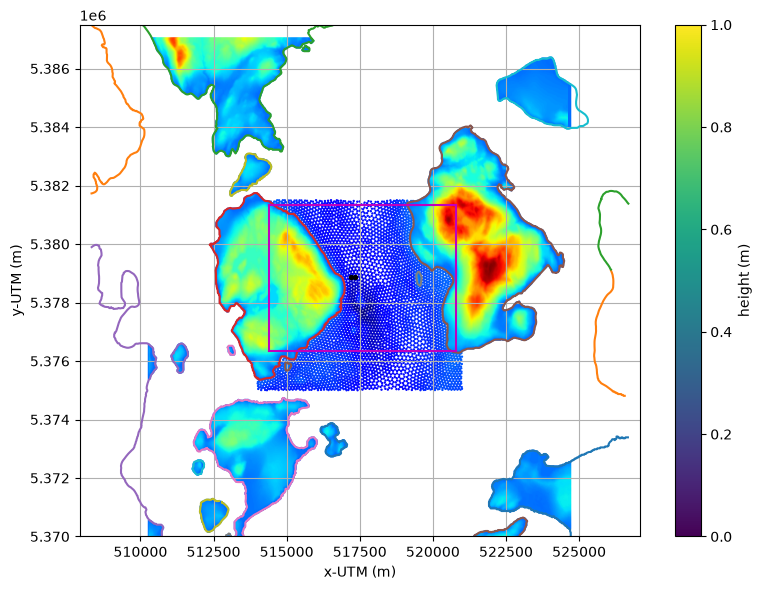

In [9]:
# Plot the merged data with the AMR-Wind domain as a check.
plt.figure(1,figsize=(8,6))
plt.scatter(x,y,c=h,s=0.5,cmap='jet')
for i in range(len(xIsland)):
    plt.plot(xIsland[i],yIsland[i])
plt.plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzLoUTM[1]],'m-')
plt.plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzHiUTM[1],xyzHiUTM[1]],'m-')
plt.plot([xyzLoUTM[0], xyzLoUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
plt.plot([xyzHiUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
plt.scatter(deploymentSTBM[0],deploymentSTBM[1],c='black',s=8)
plt.scatter(deploymentSS[0],deploymentSS[1],c='black',s=8)
         
plt.axis('equal')
plt.colorbar(label='height (m)')
plt.xlim((510000,525000))
plt.ylim((5.37E6,5.3875E6))
plt.xlabel('x-UTM (m)')
plt.ylabel('y-UTM (m)')



In [10]:
### Write the elevation data to a file AMR-Wind can read in as terrain data.  

# We now have the bathymmetry and land elevation data merged into a single data set, but it has no structure.  AMR-Wind expects a
# structured array of elevation points, so we will created a structured x-y coordinate plane and interpolate elevation data to it.


# Form the structured arrays.
nx = int(np.ceil((xyzHiUTM[0] - xyzLoUTM[0])+2.0*xBuffer)/dx)
ny = int(np.ceil((xyzHiUTM[1] - xyzLoUTM[1])+2.0*yBuffer)/dy)

xStruct = np.tile(np.linspace(xyzLoUTM[0]-xBuffer,xyzHiUTM[0]+xBuffer,nx),ny)
yStruct = np.repeat(np.linspace(xyzLoUTM[1]-yBuffer,xyzHiUTM[1]+xBuffer,ny),nx)
hStruct = np.zeros((nx*ny))


# Use SCIPY's griddata interpolator to interpolate from unstructured elevation data to structured.
hStruct = sc.interpolate.griddata((x,y),h,(xStruct,yStruct),method='linear')



# Plot the structured and unstructed depth data as a check.
# fig,axs = plt.subplots(1,2,figsize=(12,5),sharex=True, sharey=True)

# axs[0].set_title('Interpolated Structured Data')
# scat = axs[0].scatter(xStruct,yStruct,c=hStruct,cmap='jet',s=0.5)
# for i in range(len(xIsland)):
#     axs[0].plot(xIsland[i],yIsland[i])
# axs[0].plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzLoUTM[1]],'m-')
# axs[0].plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzHiUTM[1],xyzHiUTM[1]],'m-')
# axs[0].plot([xyzLoUTM[0], xyzLoUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
# axs[0].plot([xyzHiUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
# axs[0].set_xlabel('x (m) (UTM)')
# axs[0].set_ylabel('y (m) (UTM)')
# axs[0].set_xlim((xyzLoUTM[0]-xBuffer,xyzHiUTM[0]+xBuffer))
# axs[0].set_ylim((xyzLoUTM[1]-yBuffer,xyzHiUTM[1]+yBuffer))
# plt.colorbar(scat,label='depth (m)')


# axs[1].set_title('Original Data')
# scat = axs[1].scatter(x,y,c=h,cmap='jet',s=0.5)
# for i in range(len(xIsland)):
#     axs[1].plot(xIsland[i],yIsland[i])
# axs[1].plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzLoUTM[1]],'m-')
# axs[1].plot([xyzLoUTM[0], xyzHiUTM[0]],[xyzHiUTM[1],xyzHiUTM[1]],'m-')
# axs[1].plot([xyzLoUTM[0], xyzLoUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
# axs[1].plot([xyzHiUTM[0], xyzHiUTM[0]],[xyzLoUTM[1],xyzHiUTM[1]],'m-')
# axs[1].set_xlabel('x-UTM (m)')
# axs[1].set_ylabel('y-UTM (m)')
# axs[1].set_xlim((xyzLoUTM[0]-xBuffer,xyzHiUTM[0]+xBuffer))
# axs[1].set_ylim((xyzLoUTM[1]-yBuffer,xyzHiUTM[1]+yBuffer))
# plt.colorbar(scat,label='depth (m)')



# Write the bathymmetry and land height data as an AMR-Wind terrain file using Matt's writer function that's in his 
# inflowPrepMMC module.
elevData = mmc.inflowPrepMMC()
elevData.writeAMRWindTerrain(np.transpose(np.reshape(xStruct - xyzLoUTM[0] + xyzLo[0],(ny,nx))),
                             np.transpose(np.reshape(yStruct - xyzLoUTM[1] + xyzLo[1],(ny,nx))),
                             np.transpose(np.reshape(hStruct - xyzLoUTM[2] + xyzLo[2],(ny,nx))), 
                             terrainFile)





Writing AMR-Wind immersed boundary terrain file...


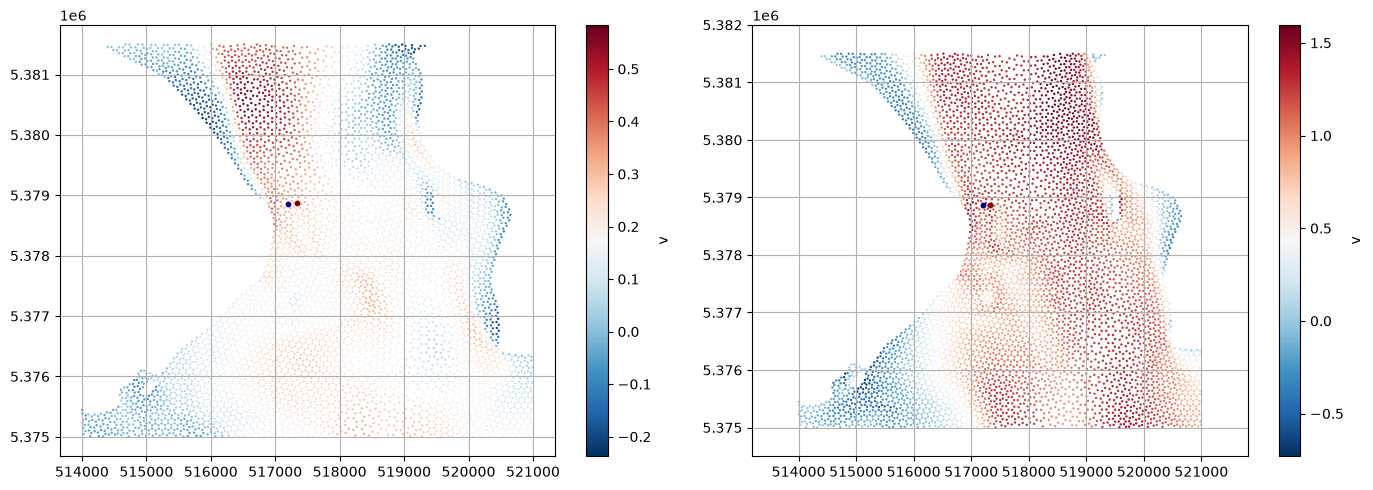

In [ ]:
# Plot some of the data.  Choose the field, the time, and the sigma level.

field0 = v
t0 = timeIndex[0]
sig0 = 1

field1 = v
t1 = timeIndex[1]
sig1 = 1


if len(field0.shape) == 3:
    color0 = field0[t0,sig0,:]
elif len(field0.shape) == 2:
    if field0.shape[0] == time0.shape[0]:
        color0 = field0[t0,:]
    else:
        color0 = field[sig0,:]
        #colorin0 = field[sig0,iin]
elif len(field.shape) == 1:
    color0 = field0

if len(field1.shape) == 3:
    color1 = field1[t1,sig1,:]
    #colorin1 = field1[t1,sig1,iin]
elif len(field1.shape) == 2:
    if field1.shape[0] == time1.shape[0]:
        color1 = field1[t1,:]
    else:
        color1 = field[sig1,:]
        #colorin1 = field[sig1,iin]
elif len(field.shape) == 1:
    color1 = field1



fig,axs = plt.subplots(1,2,figsize=(14,5))

scat0 = axs[0].scatter(xBathymetry,yBathymetry,c=color0,cmap='RdBu_r',s=0.5)
axs[0].scatter(deploymentSTBM[0],deploymentSTBM[1],c='darkblue',s=10)
axs[0].scatter(deploymentSS[0],deploymentSS[1],c='darkred',s=10)
plt.axis('equal')
plt.colorbar(scat0,label='v')

scat1 = axs[1].scatter(xBathymetry,yBathymetry,c=color1,cmap='RdBu_r',s=0.5)
axs[1].scatter(deploymentSTBM[0],deploymentSTBM[1],c='darkblue',s=10)
axs[1].scatter(deploymentSS[0],deploymentSS[1],c='darkred',s=10)
plt.axis('equal')
plt.colorbar(scat1,label='v')

plt.show()




xBathymetryI = np.zeros((siglay.shape[0],len(xBathymetry)))
yBathymetryI = np.zeros((siglay.shape[0],len(xBathymetry)))
zBathymetryI = np.zeros((siglay.shape[0],len(xBathymetry)))
for i in range(siglay.shape[0]):
    xBathymetryI[i,:] = xBathymetry
    yBathymetryI[i,:] = yBathymetry
    zBathymetryI[i,:] = hBathymetry - (zeta[t1,:] - hBathymetry)*siglay[i,:]

interpolator_vN = NearestNDInterpolator(list(zip(xBathymetryI.flatten(),
                                                 yBathymetryI.flatten(),
                                                 zBathymetryI.flatten())),
                                        v[t1,:,:].flatten())
interpolator_vL =  LinearNDInterpolator(list(zip(xBathymetryI.flatten(),
                                                 yBathymetryI.flatten(),
                                                 zBathymetryI.flatten())),
                                        v[t1,:,:].flatten())
interpolator_h = LinearNDInterpolator(list(zip(x,y)),h)




xI_ = np.linspace(xyzLoUTM[0],xyzHiUTM[0],1280)
zI_ = np.linspace(xyzLoUTM[2],xyzHiUTM[2],896)
yI_ = xyzLoUTM[1]*np.ones(xI_.shape)
xI,zI = np.meshgrid(xI_,zI_)
yI = xyzLoUTM[1]*np.ones(xI.shape)

vNI = interpolator_vN(xI,yI,zI)
vLI = interpolator_vL(xI,yI,zI)
hI_ = interpolator_h(xI_,yI_)

plt.figure(10,figsize=(20,4))
plt.pcolor(xI,zI,vNI,cmap='RdBu_r',vmin=-1.0,vmax=1.0)
plt.colorbar()
plt.plot(xI_,hI_,'k-')
plt.ylim(-150,100)
plt.xlabel('x-UTM (m)')
plt.ylabel('z (m)')

plt.figure(11,figsize=(20,4))
plt.pcolor(xI,zI,vLI,cmap='RdBu_r',vmin=-1.0,vmax=1.0)
plt.colorbar()
plt.plot(xI_,hI_,'k-')
plt.ylim(-150,100)
plt.xlabel('x-UTM (m)')
plt.ylabel('z (m)')



minimum distance cells: 4028   distance to deployment location: 32.656057912850784 m


Text(0, 0.5, 'sigma layer depth')

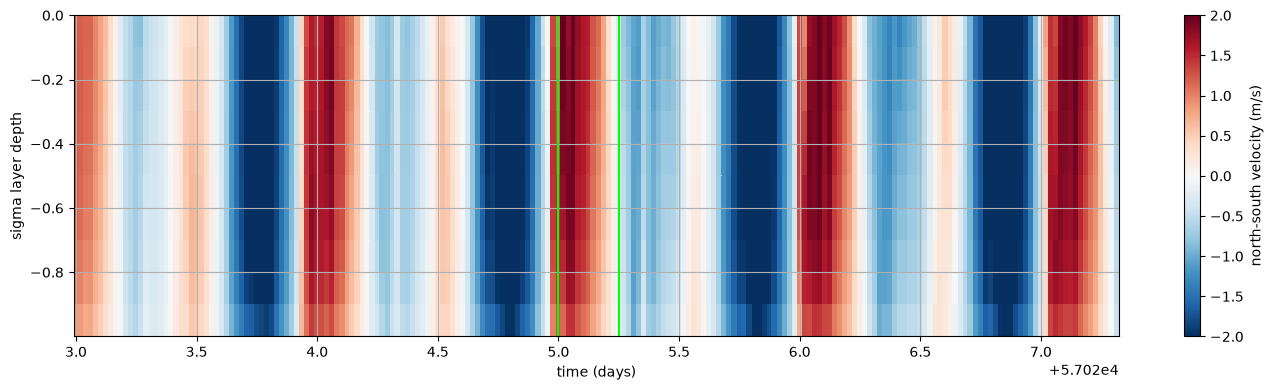

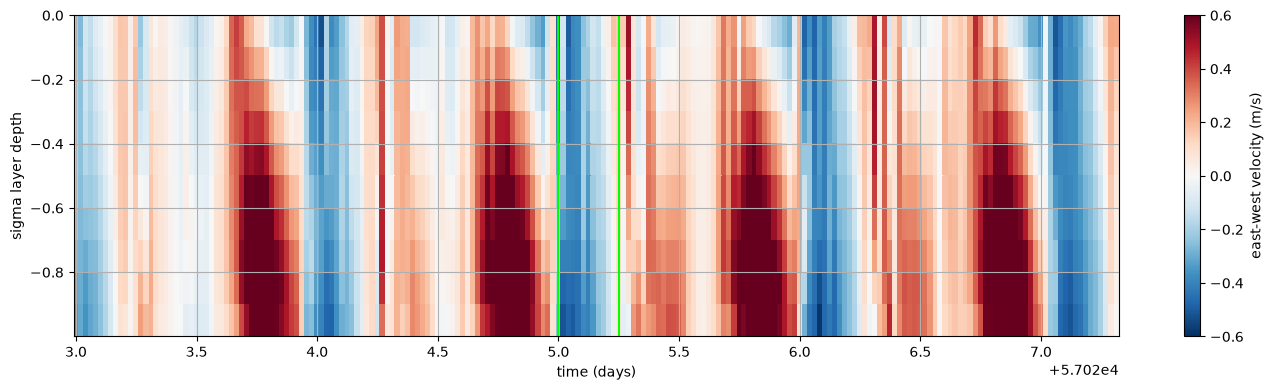

In [30]:
### Plot temporal evolution of flow in deployment location.

# Find the index of the grid column nearest the deployment location.
distToDeployment = np.zeros(np.shape(xBathymetry))

deploymentLocation = deploymentSS

for i in range(len(xBathymetry)):
    distToDeployment[i] = np.sqrt(np.square(deploymentLocation[0] - xBathymetry[i]) + 
                                  np.square(deploymentLocation[1] - yBathymetry[i]))

minDistIndex = np.argmin(distToDeployment)
print('minimum distance cells:',minDistIndex,'  distance to deployment location:',distToDeployment[minDistIndex],'m')



# Plot the u, v velocity time-height variation.
plt.figure(0,figsize=(14,4))
plt.pcolor(time,siglay[:,minDistIndex],np.transpose(v[:,:,minDistIndex]),vmin=-2.0,vmax=2.0,cmap='RdBu_r')
plt.axvline(time[timeIndex[0]],c='lime')
plt.axvline(time[timeIndex[1]],c='lime')
plt.colorbar(label='north-south velocity (m/s)')
plt.xlabel('time (days)')
plt.ylabel('sigma layer depth')

plt.figure(1,figsize=(14,4))
plt.pcolor(time,siglay[:,minDistIndex],np.transpose(u[:,:,minDistIndex]),vmin=-0.6,vmax=0.6,cmap='RdBu_r')
plt.axvline(time[timeIndex[0]],c='lime')
plt.axvline(time[timeIndex[1]],c='lime')
plt.colorbar(label='east-west velocity (m/s)')
plt.xlabel('time (days)')
plt.ylabel('sigma layer depth')





Processing boundary: xlo
Initializing AMReX (26.06)...
OMP initialized with 1 OMP threads
AMReX (26.06) initialized


TinyProfiler total time across processes [min...avg...max]: 0.09716 ... 0.09716 ... 0.09716

-------------------------------------------------------------------------------------------
Name                                        NCalls  Excl. Min  Excl. Avg  Excl. Max   Max %
-------------------------------------------------------------------------------------------
FabArray::setVal()                               3   0.002226   0.002226   0.002226   2.29%
Other                                            6  2.724e-05  2.724e-05  2.724e-05   0.03%
-------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------
Name                                        NCalls  Incl. Min  Incl. Avg  Incl. Max   Max %
----------------------------------------------------

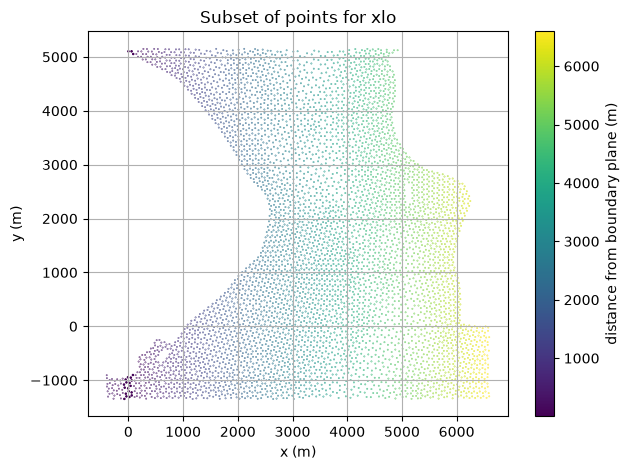

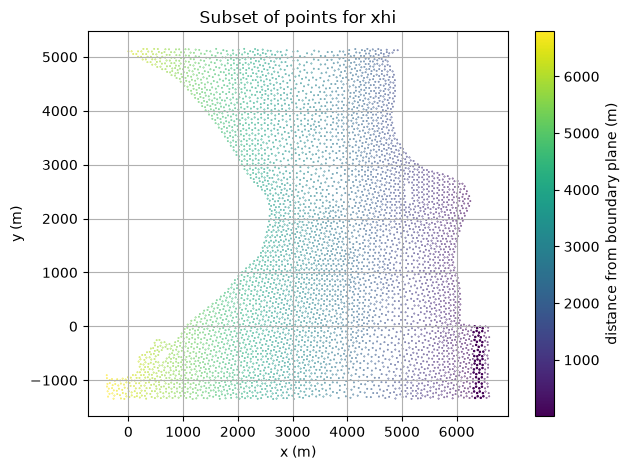

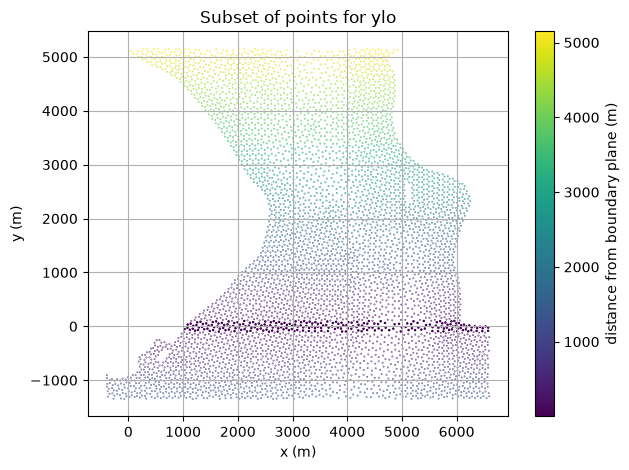

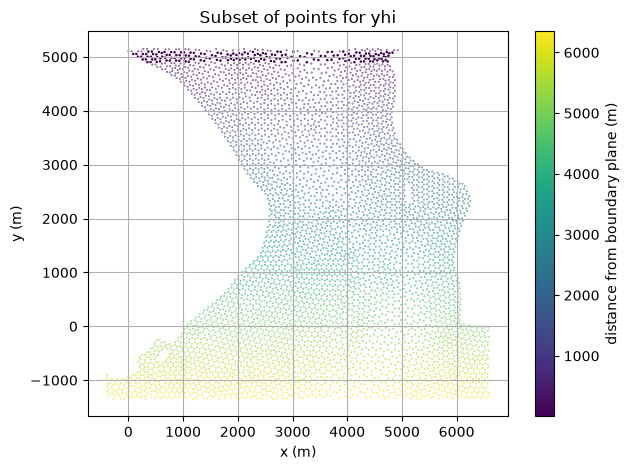

In [11]:
# Get data on lateral boundaries and write as AMR-Wind boundary data.


# Time is given in days, so convert to seconds from first FVCOM output.
timeSeconds = (time-time[0])*(24.0*3600.0)


#   Loop over boundaries.
for boundary_ in range(len(boundaries)):
    print("Processing boundary: " + boundaries[boundary_])

    

    # Set the boundary number.  This does not support zlo and zhi boundaries.  We should not need those for estuary flow, but
    # if we really need it, this can be reworked--just let Matt know.
    match boundaries[boundary_]:
        case 'xlo':
            orientation = 0
            boundaryNormal = [ 1,  0]
        case 'ylo':
            orientation = 1
            boundaryNormal = [ 0,  1]
        case 'xhi':
            orientation = 3
            boundaryNormal = [ 1,  0]
        case 'yhi':
            orientation = 4
            boundaryNormal = [ 0,  1]


    # Interpolation from FVCOM data to AMR-Wind data takes substantial time, so this part attempts to speed up the interpolation
    # by finding a subset of FVCOM data within some smallish distance of the boundary plane from which to interpolate.
    
    # Get the boundary plane's bounds by reading the AMR-Wind input file.
    amr.initialize([])
    bdir = pathlib.Path(AMRWindBoundaryDataDirectory)
    odir = bdir / f"bndry_output{0:05d}"
    bp = nbp.NativeBoundaryPlane(fields[0], components[0], orientation, odir)
    bp.define_from_file(AMRWindInputFile, 0, timeSeconds[0])
    amr.finalize()
    planeLo = bp.prob_lo
    planeHi = bp.prob_hi

    # Midpoint of boundary
    planeMid = [0.5*(planeLo[0]+planeHi[0]),0.5*(planeLo[1]+planeHi[1])]

    # Compute distance normal to the boundary plane.
    dist = np.abs(np.transpose([(xBathymetry - xyzLoUTM[0] + xyzLo[0]) - planeMid[0],
                                (yBathymetry - xyzLoUTM[1] + xyzLo[1]) - planeMid[1]]) @ boundaryNormal)

    # Find the subset of FVCOM points that are within 'interpSubsetDist' from the plane.  This is a true/false list.
    iSubset = np.array(dist < interpSubsetDist)
    print('Interpolation subset is ',np.round(100.0*(np.sum(iSubset)/len(dist)),1),'% of full FVCOM point set.')

    
    # Plot the subset of points.
    plt.figure(boundary_)
    plt.title('Subset of points for ' + boundaries[boundary_])
    plt.scatter(xBathymetry - xyzLoUTM[0] + xyzLo[0], yBathymetry - xyzLoUTM[1] + xyzLo[1], 
                vmin=np.min(dist),vmax=np.max(dist),c=dist,s=0.1)
    plt.scatter(xBathymetry[iSubset] - xyzLoUTM[0] + xyzLo[0], yBathymetry[iSubset] - xyzLoUTM[1] + xyzLo[1] ,
                vmin=np.min(dist),vmax=np.max(dist),c=dist[iSubset],s=0.6)
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.colorbar(label='distance from boundary plane (m)')




    
    # Create the x,y data (z comes later because it is time dependent).  First index is grid column; second index is height 
    # position in column.
    subsetSize = np.sum(iSubset)
    xWaterVol = np.zeros((siglay.shape[0],subsetSize))
    yWaterVol = np.zeros((siglay.shape[0],subsetSize))
    
    # x/y data are fixed in time, so set them once now.
    for i in range(xWaterVol.shape[0]):
        xWaterVol[i,:] = xBathymetry[iSubset]
        yWaterVol[i,:] = yBathymetry[iSubset]
    
    # Flatten the data.
    xWaterVol = xWaterVol.flatten()
    yWaterVol = yWaterVol.flatten()



    
    # Loop over times
    for time_ in range(timeIndex[0],timeIndex[1]+1):
        print('day = ',time[time_]-time[0])

        
        # Initialize amrex.space3d.
        amr.initialize([])

        # Get the z variable as z = bathymetryElevation - (waterSurfaceHeight - bathymetryElevaton) * sigma.  We loop 
        # over the sigma levels.  z changes every time step because water height changes in time.
        zWaterVol = np.zeros((siglay.shape[0],subsetSize))
        for i in range(zWaterVol.shape[0]):
            zWaterVol[i,:] = hBathymetry[iSubset] - (zeta[time_,iSubset] - hBathymetry[iSubset])*siglay[i,iSubset]

        # Load the current time's water velocity.
        uWaterVol = np.transpose(u[time_,:,iSubset])
        vWaterVol = np.transpose(v[time_,:,iSubset])


        # Flatten the data.
        zWaterVol = zWaterVol.flatten()
        uWaterVol = uWaterVol.flatten()
        vWaterVol = vWaterVol.flatten()

        
        # Translate coordinates to match AMR-Wind terrain coordinates.
        xWaterVol_ = xWaterVol - xyzLoUTM[0] + xyzLo[0]
        yWaterVol_ = yWaterVol - xyzLoUTM[1] + xyzLo[1]
        zWaterVol_ = zWaterVol - xyzLoUTM[2] + xyzLo[2]

        x_ = x - xyzLoUTM[0] + xyzLo[0]
        y_ = y - xyzLoUTM[1] + xyzLo[1]

        xBathymetry_ = xBathymetry - xyzLoUTM[0] + xyzLo[0]
        yBathymetry_ = yBathymetry - xyzLoUTM[1] + xyzLo[1]

        # Set up the interpolators.  If the domain boundary does not cross through water, the subset size is zero
        # and the interpolators for velocity are empty.
        interpolator_u = []
        interpolator_v = []
        interpolator_zeta = []
        interpolator_h = []
        if (subsetSize > 0):
            if (interpolatorTypeVelocity == 'linear'):
                interpolator_u = LinearNDInterpolator(list(zip(xWaterVol_,yWaterVol_,zWaterVol_)), uWaterVol)
                interpolator_v = LinearNDInterpolator(list(zip(xWaterVol_,yWaterVol_,zWaterVol_)), vWaterVol)
            else:
                interpolator_u = NearestNDInterpolator(list(zip(xWaterVol_,yWaterVol_,zWaterVol_)), uWaterVol)
                interpolator_v = NearestNDInterpolator(list(zip(xWaterVol_,yWaterVol_,zWaterVol_)), vWaterVol)

        if (interpolatorTypeZeta == 'linear'):
            interpolator_zeta = LinearNDInterpolator(list(zip(xBathymetry_,yBathymetry_)),zeta[time_,:])
        else:
            interpolator_zeta = NearestNDInterpolator(list(zip(xBathymetry_,yBathymetry_)),zeta[time_,:])

        if (interpolatorTypeHeight == 'linear'):
            interpolator_h = LinearNDInterpolator(list(zip(x_,y_)),h)
        else:
            interpolator_h = NearestNDInterpolator(list(zip(x_,y_)),h)




        # Loop over fields.
        for field_ in range(len(fields)):

            # Set the path to where boundary data files should be written.  Warn if already exists unless the overwrite option is provided.
            bdir = pathlib.Path(AMRWindBoundaryDataDirectory)
            if (bdir.exists() and not AMRWindBoundaryDataOverwrite):
                print('Boundary data already exists')


            # Set the functors used to transfer the data to the AMR-Wind boundary.  See the boundaryDataFunctor.py for details.
            fieldFunctor = {}
            vecCompName = ["x","y","z"]
            for comp_ in range(components[field_]):
                if (components[field_] == 3):
                    fieldName = fields[field_] + vecCompName[comp_]
                else:
                    fieldName = fields[field_]

                # For velocity, use interpolation if the subset size is > 0, otherwise set to 0.  Always set w to 0.  The interpolation,
                # though, sets velocity subterrain and in the air to a specified value.
                if (fields[field_] == 'velocity'):
                    if (comp_ == 0):
                        if (subsetSize > 0):
                            fieldFunctor[fieldName] = boundaryDataFunctors.InterpolatedEstuaryVelocity(interpolator_u,interpolator_h,interpolator_zeta,terrainVel[0],airVel[0])
                        else:
                            fieldFunctor[fieldName] = boundaryDataFunctors.Constant(0.0)
                    elif (comp_ == 1):
                        if (subsetSize > 0):
                            fieldFunctor[fieldName] = boundaryDataFunctors.InterpolatedEstuaryVelocity(interpolator_v,interpolator_h,interpolator_zeta,terrainVel[1],airVel[1])
                        else:
                            fieldFunctor[fieldName] = boundaryDataFunctors.Constant(0.0)
                    elif (comp_ == 2):
                        fieldFunctor[fieldName] = boundaryDataFunctors.Constant(0.0)

                # For density and vof, set the the proper value for air or water if above or below water level with the blend at the
                # interface.  Disregard terrain.
                elif (fields[field_] == 'density'):
                    fieldFunctor[fieldName] = boundaryDataFunctors.InterpolatedEstuaryDensityVOF(interpolator_zeta,waterDensity,airDensity)
                    
                elif (fields[field_] == 'vof'):
                    fieldFunctor[fieldName] = boundaryDataFunctors.InterpolatedEstuaryDensityVOF(interpolator_zeta,waterVOF,airVOF)

                
            # Generate the boundary data and write using Marc Henry de Frahan's NativeBoundaryPlane class.
            odir = bdir / f"bndry_output{time_-timeIndex[0]:05d}"
            bp = nbp.NativeBoundaryPlane(fields[field_], components[field_], orientation, odir)
            bp.define_from_file(AMRWindInputFile, time_-timeIndex[0], timeSeconds[time_])
            bp.evaluate(fieldFunctor)
            bp.write()


        

        # Finalize amrex.space3d.  If you don't do this and you run this cell again, the kernal crashes.
        amr.finalize()



# Save the time information.
steps = [i for i in range(timeIndex[0],timeIndex[1]+1)]
steps = steps - (steps[0])*np.ones(len(steps))
np.savetxt(bdir / "time.dat", np.c_[steps, timeSeconds[timeIndex[0]:timeIndex[1]+1]-timeSeconds[timeIndex[0]]], fmt="%.17g")





In [12]:
### Write a level-0 Kynema-SGF checkpoint from the FVCOM initial condition.

# This checkpoint intentionally contains only the coarsest AMR level. Kynema-SGF
# can refine the hierarchy after restart using its normal tagging criteria.
checkpointDirectory = pathlib.Path('/scratch/mkuhn/estuary_flows/milestone/chk00000')
checkpointTime = 0.0
checkpointStep = 0
checkpointDt = 0.0

amr.initialize([])
try:
    xyzLo, xyzHi, nCell, nLevels, refRatio, cellSizes = nbp.parse_input_file(AMRWindInputFile)
    domain = amr.Box(amr.IntVect(0), amr.IntVect(nCell[0] - 1, nCell[1] - 1, nCell[2] - 1))
    boxArray = amr.BoxArray(domain)
    distributionMapping = amr.DistributionMapping(boxArray)
    # Kynema-SGF's pressure field is nodal, unlike the other checkpoint fields.
    # surroundingNodes() mutates in place, so convert a copy, not boxArray itself.
    pressureBoxArray = amr.BoxArray(boxArray)
    pressureBoxArray.surroundingNodes()

    # Initialize the full FVCOM interpolators at the checkpoint time.
    checkpointTimeIndex = timeIndex[0]
    sigmaCount = siglay.shape[0]
    xWater = np.tile(xBathymetry, sigmaCount) - xyzLoUTM[0] + xyzLo[0]
    yWater = np.tile(yBathymetry, sigmaCount) - xyzLoUTM[1] + xyzLo[1]
    zWater = np.empty((sigmaCount, len(xBathymetry)))
    for sigmaIndex in range(sigmaCount):
        zWater[sigmaIndex, :] = hBathymetry - (zeta[checkpointTimeIndex, :] - hBathymetry) * siglay[sigmaIndex, :]
    zWater = zWater.ravel() - xyzLoUTM[2] + xyzLo[2]

    interpolatorU = NearestNDInterpolator(list(zip(xWater, yWater, zWater)), u[checkpointTimeIndex, :, :].T.ravel())
    interpolatorV = NearestNDInterpolator(list(zip(xWater, yWater, zWater)), v[checkpointTimeIndex, :, :].T.ravel())
    interpolatorZeta = NearestNDInterpolator(
        list(zip(xBathymetry - xyzLoUTM[0] + xyzLo[0], yBathymetry - xyzLoUTM[1] + xyzLo[1])),
        zeta[checkpointTimeIndex, :],
    )
    interpolatorHeight = LinearNDInterpolator(
        list(zip(x - xyzLoUTM[0] + xyzLo[0], y - xyzLoUTM[1] + xyzLo[1])), h - xyzLoUTM[2] + xyzLo[2]
    )

    checkpointFields = {
        'density': amr.MultiFab(boxArray, distributionMapping, 1, 0),
        'gp': amr.MultiFab(boxArray, distributionMapping, 3, 0),
        'p': amr.MultiFab(pressureBoxArray, distributionMapping, 1, 0),
        'velocity': amr.MultiFab(boxArray, distributionMapping, 3, 0),
        'vof': amr.MultiFab(boxArray, distributionMapping, 1, 0),
    }
    for field in checkpointFields.values():
        field.set_val(0.0)

    densityFunctor = boundaryDataFunctors.InterpolatedEstuaryDensityVOF(interpolatorZeta, waterDensity, airDensity)
    vofFunctor = boundaryDataFunctors.InterpolatedEstuaryDensityVOF(interpolatorZeta, waterVOF, airVOF)
    velocityFunctors = [
        boundaryDataFunctors.InterpolatedEstuaryVelocity(interpolatorU, interpolatorHeight, interpolatorZeta, terrainVel[0], airVel[0]),
        boundaryDataFunctors.InterpolatedEstuaryVelocity(interpolatorV, interpolatorHeight, interpolatorZeta, terrainVel[1], airVel[1]),
    ]

    for gridIndex in range(boxArray.size):
        fieldData = checkpointFields['density'].to_xp()[gridIndex]
        box = boxArray[gridIndex]
        coordinates = [
            xyzLo[dimension] + (np.arange(box.small_end[dimension], box.big_end[dimension] + 1) + 0.5) * cellSizes[0][dimension]
            for dimension in range(3)
        ]
        xGrid, yGrid, zGrid = np.meshgrid(*coordinates, indexing='ij')
        fieldData[:, :, :, 0] = densityFunctor(xGrid, yGrid, zGrid, checkpointTime)
        checkpointFields['vof'].to_xp()[gridIndex][:, :, :, 0] = vofFunctor(xGrid, yGrid, zGrid, checkpointTime)
        checkpointFields['velocity'].to_xp()[gridIndex][:, :, :, 0] = velocityFunctors[0](xGrid, yGrid, zGrid, checkpointTime)
        checkpointFields['velocity'].to_xp()[gridIndex][:, :, :, 1] = velocityFunctors[1](xGrid, yGrid, zGrid, checkpointTime)

    checkpointDirectory.mkdir(parents=True, exist_ok=True)
    levelDirectory = checkpointDirectory / 'Level_0'
    levelDirectory.mkdir(exist_ok=True)
    with open(checkpointDirectory / 'Header', 'w') as header:
        header.write('Checkpoint version: 1\n')
        header.write('0\n')
        header.write(f'{checkpointStep}\n')
        header.write(f'{checkpointTime:.17g}\n')
        header.write(f'{checkpointDt:.17g}\n')
        header.write(f'{checkpointDt:.17g}\n')
        header.write(f'{checkpointDt:.17g}\n')
        header.write(' '.join(f'{value:.17g}' for value in xyzLo) + ' \n')
        header.write(' '.join(f'{value:.17g}' for value in xyzHi) + ' \n')
        # Write in AMReX's BoxArray::writeOn text format, not pyamrex's repr.
        header.write(f'({boxArray.size} 0\n')
        for gridIndex in range(boxArray.size):
            box = boxArray[gridIndex]
            smallEnd = ','.join(str(box.small_end[dimension]) for dimension in range(3))
            bigEnd = ','.join(str(box.big_end[dimension]) for dimension in range(3))
            header.write(f'(({smallEnd}) ({bigEnd}) (0,0,0))\n')
        header.write(')\n')

    for fieldName, field in checkpointFields.items():
        amr.VisMF.Write(field, str(levelDirectory / fieldName))
finally:
    amr.finalize()

print(f'Wrote level-0 checkpoint to {checkpointDirectory}')

Initializing AMReX (26.06)...
OMP initialized with 1 OMP threads
AMReX (26.06) initialized
Wrote level-0 checkpoint to /scratch/mkuhn/estuary_flows/milestone/chk00000


TinyProfiler total time across processes [min...avg...max]: 18.27 ... 18.27 ... 18.27

-------------------------------------------------------------------------------------------
Name                                        NCalls  Excl. Min  Excl. Avg  Excl. Max   Max %
-------------------------------------------------------------------------------------------
VisMF::Write(FabArray)                           5     0.1757     0.1757     0.1757   0.96%
Other                                            7    0.04825    0.04825    0.04825   0.26%
-------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------
Name                                        NCalls  Incl. Min  Incl. Avg  Incl. Max   Max %
-------